# Coefficient Variance

This notebook saves the L=1/L=2 comparison figures `figures/figure3_variance_values_comparison.png` and `figures/figure3_variance_ratio_comparison.png`.

For the selected hyperoctahedral orbit $[\nu_n]$, it compares $\operatorname{Var}(a_{\nu_n})$ with the mean individual coefficient variance on that orbit.


## Parameters

Set the circuit, sampling, and figure-output parameters.


In [25]:
from dataclasses import dataclass
from pathlib import Path
import itertools
import math
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch


# Output.
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DPI = 300
VALUES_COMPARISON_FIGURE_PATH = FIGURE_DIR / "figure3_variance_values_comparison.png"
RATIO_COMPARISON_FIGURE_PATH = FIGURE_DIR / "figure3_variance_ratio_comparison.png"
DATA_DIR = Path("training_data")
L2_DATA_PATH = DATA_DIR / "figure3_variance_L2.npz"
L1_DATA_PATH = DATA_DIR / "figure3_variance_L1.npz"

# Experiment parameters.
QUBIT_COUNTS = (1, 2, 3, 4, 5)
N_UPLOAD_LAYERS = 2
ENCODING_BASE = 3
N_PARAMETER_SAMPLES = 10000
MAX_GRID_POINTS = 1_000_000
SELECTED_ORBIT_FREQUENCY = None  # None means auto-wrap (1, 2, ..., n) into 1, ..., M.
WRAP_SELECTED_ORBIT_FREQUENCY = True
USE_DOUBLE_PRECISION = False

REAL_DTYPE = torch.float64 if USE_DOUBLE_PRECISION else torch.float32
COMPLEX_DTYPE = torch.complex128 if USE_DOUBLE_PRECISION else torch.complex64


def binomial(n, k):
    if hasattr(math, "comb"):
        return math.comb(n, k)
    return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))


@dataclass
class ExperimentConfig:
    qubit_counts: tuple = QUBIT_COUNTS
    n_upload_layers: int = N_UPLOAD_LAYERS
    encoding_base: int = ENCODING_BASE
    n_parameter_samples: int = N_PARAMETER_SAMPLES
    blocks_per_trainable_layer: object = None
    selected_orbit_frequency: object = SELECTED_ORBIT_FREQUENCY
    wrap_selected_orbit_frequency: bool = WRAP_SELECTED_ORBIT_FREQUENCY
    setting_name: str = "deeper setting"
    seed: int = 2026
    prefer_mps: bool = True
    max_grid_points: int = MAX_GRID_POINTS
    real_dtype: torch.dtype = REAL_DTYPE
    complex_dtype: torch.dtype = COMPLEX_DTYPE

    @property
    def omega_max(self):
        return sum(self.encoding_base**layer for layer in range(self.n_upload_layers))

    @property
    def nx(self):
        # Nyquist grid for integer frequencies in [-omega_max, omega_max].
        return 2 * self.omega_max + 1


CONFIG = ExperimentConfig(
    qubit_counts=QUBIT_COUNTS,
    n_upload_layers=N_UPLOAD_LAYERS,
    encoding_base=ENCODING_BASE,
    n_parameter_samples=N_PARAMETER_SAMPLES,
    max_grid_points=MAX_GRID_POINTS,
    blocks_per_trainable_layer=5,
    setting_name=r"2-design",
)
BLOCK1_CONFIG = ExperimentConfig(
    qubit_counts=CONFIG.qubit_counts,
    n_upload_layers=CONFIG.n_upload_layers,
    encoding_base=CONFIG.encoding_base,
    n_parameter_samples=CONFIG.n_parameter_samples,
    blocks_per_trainable_layer=1,
    selected_orbit_frequency=CONFIG.selected_orbit_frequency,
    wrap_selected_orbit_frequency=CONFIG.wrap_selected_orbit_frequency,
    setting_name=r"approximate 2-design",
    seed=CONFIG.seed,
    prefer_mps=CONFIG.prefer_mps,
    max_grid_points=CONFIG.max_grid_points,
    real_dtype=CONFIG.real_dtype,
    complex_dtype=CONFIG.complex_dtype,
)
mpl.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 17,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.15,
    "figure.dpi": 140,
})


## Simulator

Use the vectorized Fourier-grid simulator for the coefficient sweep.


In [26]:
def complex_exp(angle):
    """Return exp(i * angle) without relying on Python complex scalar promotion."""
    return torch.complex(torch.cos(angle), torch.sin(angle))


def choose_torch_device(prefer_mps=True):
    candidates = []
    if prefer_mps and torch.backends.mps.is_available():
        candidates.append("mps")
    if torch.cuda.is_available():
        candidates.append("cuda")
    candidates.append("cpu")

    for name in candidates:
        device = torch.device(name)
        try:
            test = torch.eye(2, dtype=torch.complex64, device=device)
            batch = torch.ones((4, 2), dtype=torch.complex64, device=device)
            index = torch.tensor([1, 0], dtype=torch.long, device=device)
            _ = (test @ test).real.sum().item()
            _ = torch.matmul(batch, test.T).real.sum().item()
            _ = torch.index_select(batch, -1, index).real.sum().item()
            return device
        except Exception as exc:
            print(f"Skipping {name}: complex matmul is unavailable ({exc})")
    return torch.device("cpu")


DEVICE = choose_torch_device(CONFIG.prefer_mps)
print(f"Using torch device: {DEVICE}")
print(f"grid size per n: Nx = {CONFIG.nx}, omega_max = {CONFIG.omega_max}")


def basis_bits(n_qubits, device):
    # Precompute bit tables on CPU. This avoids MPS integer bitwise-kernel limitations.
    dim = 2**n_qubits
    bits = np.array(
        [[(basis >> (n_qubits - 1 - wire)) & 1 for wire in range(n_qubits)] for basis in range(dim)],
        dtype=np.int64,
    )
    return torch.tensor(bits, dtype=torch.long, device=device)


def input_grid(n_qubits, nx, device, dtype):
    values = torch.linspace(0.0, 2.0 * math.pi, nx + 1, dtype=dtype)[:-1]
    points = torch.cartesian_prod(*([values] * n_qubits))
    if points.ndim == 1:
        points = points[:, None]
    return points.to(device)


def initial_states(n_grid, n_qubits, device, complex_dtype):
    states = torch.zeros((n_grid, 2**n_qubits), dtype=complex_dtype, device=device)
    states[:, 0] = 1.0 + 0.0j
    return states


def rz_gate(theta, complex_dtype):
    diagonal = torch.stack([complex_exp(-0.5 * theta), complex_exp(0.5 * theta)]).to(complex_dtype)
    return torch.diag(diagonal)


def ry_gate(theta, complex_dtype):
    c = torch.cos(0.5 * theta)
    s = torch.sin(0.5 * theta)
    return torch.stack([
        torch.stack([c, -s]),
        torch.stack([s, c]),
    ]).to(complex_dtype)


def rot_gate(phi, theta, omega, complex_dtype):
    return rz_gate(omega, complex_dtype) @ ry_gate(theta, complex_dtype) @ rz_gate(phi, complex_dtype)


def apply_single_qubit_gate(states, gate, wire, n_qubits):
    original_shape = states.shape
    tensor = states.reshape(-1, *([2] * n_qubits))
    tensor = torch.movedim(tensor, wire + 1, -1)
    tensor = torch.matmul(tensor, gate.T)
    tensor = torch.movedim(tensor, -1, wire + 1)
    return tensor.reshape(original_shape)


def cnot_gather_index(n_qubits, control, target, device):
    dim = 2**n_qubits
    gather = np.empty(dim, dtype=np.int64)
    for old_index in range(dim):
        bits = [(old_index >> (n_qubits - 1 - wire)) & 1 for wire in range(n_qubits)]
        new_bits = bits.copy()
        if bits[control] == 1:
            new_bits[target] ^= 1
        new_index = 0
        for bit in new_bits:
            new_index = (new_index << 1) | bit
        gather[new_index] = old_index
    return torch.tensor(gather, dtype=torch.long, device=device)


def entangler_pairs(n_qubits, block_index):
    if n_qubits <= 1:
        return []
    entangling_range = (block_index % (n_qubits - 1)) + 1
    return [(wire, (wire + entangling_range) % n_qubits) for wire in range(n_qubits)]


def apply_trainable_layer(states, weights_layer, cnot_cache, n_qubits, complex_dtype):
    n_blocks = weights_layer.shape[0]
    for block in range(n_blocks):
        for wire in range(n_qubits):
            phi, theta, omega = weights_layer[block, wire]
            gate = rot_gate(phi, theta, omega, complex_dtype)
            states = apply_single_qubit_gate(states, gate, wire, n_qubits)
        for control, target in entangler_pairs(n_qubits, block):
            states = torch.index_select(states, -1, cnot_cache[(control, target)])
    return states


def encoding_signs(n_qubits, device, dtype):
    bits = basis_bits(n_qubits, device).to(dtype)
    return bits - 0.5


def apply_data_encoding(states, grid, signs, beta):
    # RZ(beta * x_j) on wire j gives phase exp(i * beta * x_j * (bit_j - 1/2)).
    phase_angles = (beta * grid) @ signs.T
    return states * complex_exp(phase_angles).to(states.dtype)


def local_projector_observable_diag(n_qubits, device, dtype):
    # O = (1/n) sum_j |0><0|_j is diagonal; value is the fraction of zero bits.
    bits = basis_bits(n_qubits, device).to(dtype)
    return 1.0 - bits.mean(dim=1)


def observable_expectation(states, observable_diag):
    probabilities = states.abs().square()
    return probabilities @ observable_diag


def trainable_block_count(n_qubits, config):
    rule = config.blocks_per_trainable_layer
    if rule is None or rule == "n":
        return max(int(n_qubits), 1)
    if callable(rule):
        return max(int(rule(n_qubits)), 1)
    return max(int(rule), 1)


def make_cache(n_qubits, config, device):
    n_grid = config.nx**n_qubits
    if n_grid > config.max_grid_points:
        raise ValueError(
            f"Grid has {n_grid:,} points for n={n_qubits}. "
            f"Reduce qubit_counts, n_upload_layers, or raise max_grid_points."
        )

    n_blocks = trainable_block_count(n_qubits, config)
    cnot_cache = {
        pair: cnot_gather_index(n_qubits, pair[0], pair[1], device)
        for block in range(n_blocks)
        for pair in entangler_pairs(n_qubits, block)
    }
    return {
        "grid": input_grid(n_qubits, config.nx, device, config.real_dtype),
        "signs": encoding_signs(n_qubits, device, config.real_dtype),
        "observable_diag": local_projector_observable_diag(n_qubits, device, config.real_dtype),
        "cnot_cache": cnot_cache,
    }


def random_weights(n_qubits, config, generator, device):
    n_blocks = trainable_block_count(n_qubits, config)
    shape = (config.n_upload_layers + 1, n_blocks, n_qubits, 3)
    weights = 2.0 * math.pi * torch.rand(shape, generator=generator, dtype=config.real_dtype)
    return weights.to(device)


def evaluate_function_grid(n_qubits, weights, cache, config, device):
    grid = cache["grid"]
    states = initial_states(grid.shape[0], n_qubits, device, config.complex_dtype)

    states = apply_trainable_layer(
        states, weights[0], cache["cnot_cache"], n_qubits, config.complex_dtype
    )
    for layer in range(config.n_upload_layers):
        beta = config.encoding_base**layer
        states = apply_data_encoding(states, grid, cache["signs"], beta)
        states = apply_trainable_layer(
            states, weights[layer + 1], cache["cnot_cache"], n_qubits, config.complex_dtype
        )

    values = observable_expectation(states, cache["observable_diag"])
    return values.reshape((config.nx,) * n_qubits).detach().cpu().numpy()


def coefficient_tensor(function_grid):
    # If f(x)=sum_omega c_omega exp(-i omega.x), ifftn gives c_omega on the integer grid.
    return np.fft.ifftn(function_grid)


Skipping mps: complex matmul is unavailable (Trying to convert ComplexFloat to the MPS backend but it does not have support for that dtype.)
Using torch device: cpu
grid size per n: Nx = 9, omega_max = 4


## Verification

Compare the custom simulator with PennyLane on fixed points and draw one PennyLane circuit.


2-design: max |custom - PennyLane| = 4.405e-07
approximate 2-design: max |custom - PennyLane| = 1.199e-07


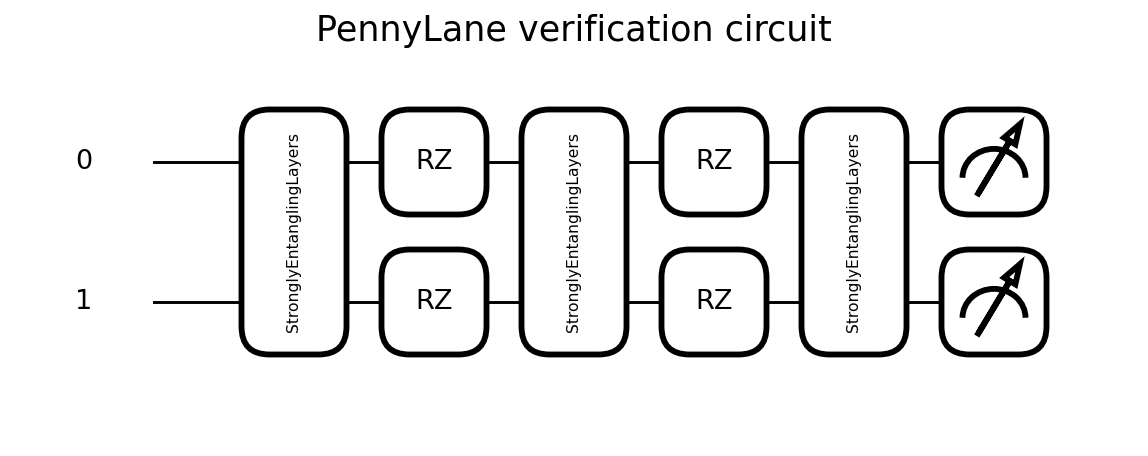

In [27]:
def evaluate_custom_points(n_qubits, x_points, weights, config, device):
    x_points = np.asarray(x_points, dtype=float)
    if x_points.ndim == 1:
        x_points = x_points[None, :]
    grid = torch.tensor(x_points, dtype=config.real_dtype, device=device)

    n_blocks = trainable_block_count(n_qubits, config)
    cnot_cache = {
        pair: cnot_gather_index(n_qubits, pair[0], pair[1], device)
        for block in range(n_blocks)
        for pair in entangler_pairs(n_qubits, block)
    }
    signs = encoding_signs(n_qubits, device, config.real_dtype)
    observable_diag = local_projector_observable_diag(n_qubits, device, config.real_dtype)

    states = initial_states(grid.shape[0], n_qubits, device, config.complex_dtype)
    states = apply_trainable_layer(states, weights[0], cnot_cache, n_qubits, config.complex_dtype)
    for layer in range(config.n_upload_layers):
        beta = config.encoding_base**layer
        states = apply_data_encoding(states, grid, signs, beta)
        states = apply_trainable_layer(states, weights[layer + 1], cnot_cache, n_qubits, config.complex_dtype)

    return observable_expectation(states, observable_diag).detach().cpu().numpy()


def make_pennylane_circuit(n_qubits, config):
    import pennylane as qml

    wires = list(range(n_qubits))
    observable_diag = local_projector_observable_diag(
        n_qubits,
        torch.device("cpu"),
        torch.float64,
    ).numpy()
    observable_matrix = np.diag(observable_diag)
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def circuit(x_vec, trainable_weights):
        qml.templates.StronglyEntanglingLayers(trainable_weights[0], wires=wires)
        for layer in range(config.n_upload_layers):
            beta = config.encoding_base**layer
            for wire in wires:
                qml.RZ(beta * x_vec[wire], wires=wire)
            qml.templates.StronglyEntanglingLayers(trainable_weights[layer + 1], wires=wires)
        return qml.expval(qml.Hermitian(observable_matrix, wires=wires))

    return circuit


def pennylane_point_values(n_qubits, x_points, weights, config):
    x_points = np.asarray(x_points, dtype=float)
    if x_points.ndim == 1:
        x_points = x_points[None, :]
    weights_np = weights.detach().cpu().numpy()
    circuit = make_pennylane_circuit(n_qubits, config)
    values = np.array([float(circuit(x_vec, weights_np)) for x_vec in x_points], dtype=float)
    return values, circuit, weights_np


def verify_pennylane_equivalence(tolerance=5.0e-5):
    verify_n_qubits = 2
    x_points = np.array(
        [
            [0.10, 0.70],
            [1.20, 2.10],
            [2.70, 0.30],
            [5.10, 4.20],
        ],
        dtype=float,
    )
    settings = [
        (CONFIG.setting_name, CONFIG),
        (BLOCK1_CONFIG.setting_name, BLOCK1_CONFIG),
    ]

    circuit_for_plot = None
    weights_for_plot = None
    for label, config in settings:
        generator = torch.Generator(device="cpu")
        generator.manual_seed(config.seed)
        weights = random_weights(verify_n_qubits, config, generator, DEVICE)
        custom_values = evaluate_custom_points(verify_n_qubits, x_points, weights, config, DEVICE)
        pennylane_values, circuit, weights_np = pennylane_point_values(
            verify_n_qubits,
            x_points,
            weights,
            config,
        )
        abs_error = np.abs(custom_values - pennylane_values)
        print(f"{label}: max |custom - PennyLane| = {abs_error.max():.3e}")
        assert abs_error.max() < tolerance, f"{label} mismatch: {abs_error.max():.3e}"
        if label == BLOCK1_CONFIG.setting_name:
            circuit_for_plot = circuit
            weights_for_plot = weights_np

    import pennylane as qml

    fig, _ = qml.draw_mpl(circuit_for_plot)(x_points[0], weights_for_plot)
    fig.suptitle("PennyLane verification circuit", y=1.02)
    plt.show()


verify_pennylane_equivalence()


## Experiment Helpers

Define orbit selection and coefficient-variance estimation.


In [28]:
def upload_betas(config):
    return tuple(int(config.encoding_base**layer) for layer in range(config.n_upload_layers))


def coordinate_frequency_values(config):
    values = {0}
    for beta in upload_betas(config):
        values = {freq + sign * beta for freq in values for sign in (-1, 0, 1)}
    return tuple(sorted(values))


def max_frequency(config):
    return max(abs(freq) for freq in coordinate_frequency_values(config))


def orbit_frequency_spectrum_size(n_qubits, config):
    return binomial(max_frequency(config) + n_qubits, n_qubits)


def positive_mod_frequency(freq, M):
    freq = abs(int(freq))
    if M <= 0:
        return 0
    if freq == 0:
        return 0
    return 1 + ((freq - 1) % M)


def wrap_orbit_frequency(frequency, M):
    return tuple(sorted(positive_mod_frequency(freq, M) for freq in frequency))


def canonical_orbit_frequency(frequency):
    return tuple(sorted(abs(int(freq)) for freq in frequency))


def default_orbit_frequency(n_qubits, config):
    return wrap_orbit_frequency(range(1, n_qubits + 1), max_frequency(config))


def selected_orbit_frequency(n_qubits, config):
    M = max_frequency(config)
    if config.selected_orbit_frequency is None:
        return default_orbit_frequency(n_qubits, config)

    frequency = canonical_orbit_frequency(config.selected_orbit_frequency)
    if len(frequency) != n_qubits:
        raise ValueError(
            f"SELECTED_ORBIT_FREQUENCY has length {len(frequency)}, but n={n_qubits}."
        )
    if frequency and frequency[-1] > M:
        if getattr(config, "wrap_selected_orbit_frequency", True):
            return wrap_orbit_frequency(frequency, M)
        raise ValueError(
            f"Selected orbit frequency {frequency} needs max frequency {frequency[-1]}, "
            f"but the spectrum only reaches M={M}. Enable WRAP_SELECTED_ORBIT_FREQUENCY or choose another orbit."
        )
    return frequency


def hyperoctahedral_orbit(orbit_frequency):
    orbit_frequency = tuple(int(freq) for freq in orbit_frequency)
    orbit = set()
    for permuted in itertools.permutations(orbit_frequency):
        for signs in itertools.product((-1, 1), repeat=len(orbit_frequency)):
            orbit.add(tuple(0 if freq == 0 else sign * freq for sign, freq in zip(signs, permuted)))
    return sorted(orbit)


def coefficient_vector_for_orbit(coeffs, orbit):
    orbit_array = np.array(orbit, dtype=int)
    indices = tuple((orbit_array[:, axis] % coeffs.shape[axis]).astype(int) for axis in range(orbit_array.shape[1]))
    return coeffs[indices]


def complex_sample_variance(samples, axis=0):
    centered = samples - np.mean(samples, axis=axis, keepdims=True)
    return np.mean(np.abs(centered) ** 2, axis=axis)


def orbit_variance_statistics(n_qubits, config, device):
    n_blocks = trainable_block_count(n_qubits, config)
    cache = make_cache(n_qubits, config, device)
    generator = torch.Generator(device="cpu")
    generator.manual_seed(config.seed)

    frequency_values = coordinate_frequency_values(config)
    base_frequency = selected_orbit_frequency(n_qubits, config)
    orbit = hyperoctahedral_orbit(base_frequency)
    orbit_size = len(orbit)

    coefficient_sum = np.zeros(orbit_size, dtype=np.complex128)
    coefficient_abs2_sum = np.zeros(orbit_size, dtype=np.float64)
    aggregate_samples = np.zeros(config.n_parameter_samples, dtype=np.complex128)

    start = time.perf_counter()
    with torch.no_grad():
        for sample in range(config.n_parameter_samples):
            weights = random_weights(n_qubits, config, generator, device)
            f_grid = evaluate_function_grid(n_qubits, weights, cache, config, device)
            coeffs = coefficient_tensor(f_grid)
            coeff_vector = coefficient_vector_for_orbit(coeffs, orbit)
            coefficient_sum += coeff_vector
            coefficient_abs2_sum += np.abs(coeff_vector) ** 2
            aggregate_samples[sample] = np.sum(coeff_vector)

    coefficient_mean = coefficient_sum / config.n_parameter_samples
    coefficient_variances = coefficient_abs2_sum / config.n_parameter_samples - np.abs(coefficient_mean) ** 2
    coefficient_variances = np.maximum(coefficient_variances.real, 0.0)
    aggregate_variance = float(complex_sample_variance(aggregate_samples, axis=0))
    mean_coefficient_variance = float(np.mean(coefficient_variances))
    sum_coefficient_variance = float(np.sum(coefficient_variances))
    ratio = float(aggregate_variance / mean_coefficient_variance) if mean_coefficient_variance > 0 else np.nan
    decoupling_ratio = (
        float(aggregate_variance / sum_coefficient_variance)
        if sum_coefficient_variance > 0
        else np.nan
    )

    return {
        "n_qubits": n_qubits,
        "n_upload_layers": config.n_upload_layers,
        "encoding_base": config.encoding_base,
        "frequency_values": frequency_values,
        "max_frequency": max_frequency(config),
        "orbit_frequency_spectrum_size": orbit_frequency_spectrum_size(n_qubits, config),
        "variance_orbit_frequency": f"nu_{n_qubits}",
        "base_orbit_frequency": base_frequency,
        "symmetry": "hyperoctahedral group Z_2^n semidirect S_n",
        "setting": config.setting_name,
        "trainable_blocks": n_blocks,
        "orbit_size": orbit_size,
        "ratio": ratio,
        "ideal_ratio": orbit_size,
        "aggregate_variance": aggregate_variance,
        "mean_coefficient_variance": mean_coefficient_variance,
        "sum_coefficient_variance": sum_coefficient_variance,
        "decoupling_ratio": decoupling_ratio,
        "elapsed_seconds": time.perf_counter() - start,
    }


def run_coefficient_variance_experiment(config=CONFIG, device=DEVICE):
    print(f"\nRunning {config.setting_name}")
    results = []
    for n_qubits in config.qubit_counts:
        stats = orbit_variance_statistics(n_qubits, config, device)
        results.append(stats)
        print(
            f"n={n_qubits:2d} | blocks={stats['trainable_blocks']:2d} | "
            f"orbit frequency={stats['variance_orbit_frequency']}={stats['base_orbit_frequency']} | "
            f"orbit size={stats['orbit_size']:7d} | "
            f"Var(a)={stats['aggregate_variance']:.3e} | "
            f"mean Var(c)={stats['mean_coefficient_variance']:.3e} | "
            f"time={stats['elapsed_seconds']:6.2f}s"
        )
    return results


## Run Or Load Data

Load the saved L=2 and L=1 results. Set the run flags to regenerate a data file.


In [29]:
RESULT_FIELDS = (
    "n_qubits",
    "n_upload_layers",
    "encoding_base",
    "max_frequency",
    "orbit_frequency_spectrum_size",
    "trainable_blocks",
    "orbit_size",
    "ratio",
    "ideal_ratio",
    "aggregate_variance",
    "mean_coefficient_variance",
    "sum_coefficient_variance",
    "decoupling_ratio",
)
TEXT_FIELDS = (
    "variance_orbit_frequency",
    "base_orbit_frequency",
    "setting",
)

# Keep these False when only replotting from saved data. For a smoke test, set FIGURE3_RUN_SAMPLES = 1.
RUN_L2_EXPERIMENT = True
RUN_L1_EXPERIMENT = True
FIGURE3_RUN_SAMPLES = N_PARAMETER_SAMPLES


def make_config_pair(n_upload_layers, samples, qubits=None):
    qubit_counts = tuple(qubits) if qubits is not None else tuple(CONFIG.qubit_counts)
    config = ExperimentConfig(
        qubit_counts=qubit_counts,
        n_upload_layers=n_upload_layers,
        encoding_base=CONFIG.encoding_base,
        n_parameter_samples=samples,
        max_grid_points=CONFIG.max_grid_points,
        blocks_per_trainable_layer=5,
        selected_orbit_frequency=CONFIG.selected_orbit_frequency,
        wrap_selected_orbit_frequency=CONFIG.wrap_selected_orbit_frequency,
        setting_name="2-design",
        seed=CONFIG.seed,
        prefer_mps=CONFIG.prefer_mps,
        real_dtype=CONFIG.real_dtype,
        complex_dtype=CONFIG.complex_dtype,
    )
    block1_config = ExperimentConfig(
        qubit_counts=qubit_counts,
        n_upload_layers=n_upload_layers,
        encoding_base=CONFIG.encoding_base,
        n_parameter_samples=samples,
        max_grid_points=CONFIG.max_grid_points,
        blocks_per_trainable_layer=1,
        selected_orbit_frequency=CONFIG.selected_orbit_frequency,
        wrap_selected_orbit_frequency=CONFIG.wrap_selected_orbit_frequency,
        setting_name="approximate 2-design",
        seed=CONFIG.seed,
        prefer_mps=CONFIG.prefer_mps,
        real_dtype=CONFIG.real_dtype,
        complex_dtype=CONFIG.complex_dtype,
    )
    return config, block1_config


def run_result_pair(n_upload_layers, samples, qubits=None):
    config, block1_config = make_config_pair(n_upload_layers, samples, qubits)
    return (
        run_coefficient_variance_experiment(config, DEVICE),
        run_coefficient_variance_experiment(block1_config, DEVICE),
    )


def result_field_values(results, field):
    values = []
    for item in results:
        value = item[field]
        if field in TEXT_FIELDS:
            value = str(value)
        values.append(value)
    return np.array(values)


def save_result_pair(path, n_upload_layers, samples, results_blocks_n, results_blocks_1, source):
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "schema_version": np.array(1),
        "n_upload_layers": np.array(n_upload_layers),
        "n_parameter_samples": np.array(samples),
        "source": np.array(source),
    }
    for prefix, results in (("blocks_n", results_blocks_n), ("blocks_1", results_blocks_1)):
        for field in RESULT_FIELDS:
            payload[f"{prefix}__{field}"] = result_field_values(results, field)
        for field in TEXT_FIELDS:
            payload[f"{prefix}__{field}"] = result_field_values(results, field)
    np.savez_compressed(path, **payload)
    print(f"saved data to {path}")


def load_result_pair(path):
    with np.load(path, allow_pickle=True) as data:
        metadata = {
            "schema_version": int(data["schema_version"]),
            "n_upload_layers": int(data["n_upload_layers"]),
            "n_parameter_samples": int(data["n_parameter_samples"]),
            "source": str(data["source"]),
        }
        result_pair = {}
        integer_fields = {
            "n_qubits",
            "n_upload_layers",
            "encoding_base",
            "max_frequency",
            "orbit_frequency_spectrum_size",
            "trainable_blocks",
            "orbit_size",
        }
        for prefix in ("blocks_n", "blocks_1"):
            n_items = len(data[f"{prefix}__n_qubits"])
            results = []
            for index in range(n_items):
                item = {}
                for field in RESULT_FIELDS:
                    value = data[f"{prefix}__{field}"][index]
                    item[field] = int(value) if field in integer_fields else float(value)
                for field in TEXT_FIELDS:
                    item[field] = str(data[f"{prefix}__{field}"][index])
                results.append(item)
            result_pair[prefix] = results
    return result_pair["blocks_n"], result_pair["blocks_1"], metadata


if RUN_L2_EXPERIMENT:
    results_L2_blocks_n, results_L2_blocks_1 = run_result_pair(2, FIGURE3_RUN_SAMPLES)
    save_result_pair(L2_DATA_PATH, 2, FIGURE3_RUN_SAMPLES, results_L2_blocks_n, results_L2_blocks_1, "fresh L=2 run")
else:
    results_L2_blocks_n, results_L2_blocks_1, metadata_L2 = load_result_pair(L2_DATA_PATH)

if RUN_L1_EXPERIMENT:
    results_L1_blocks_n, results_L1_blocks_1 = run_result_pair(1, FIGURE3_RUN_SAMPLES)
    save_result_pair(L1_DATA_PATH, 1, FIGURE3_RUN_SAMPLES, results_L1_blocks_n, results_L1_blocks_1, "fresh L=1 run")
else:
    results_L1_blocks_n, results_L1_blocks_1, metadata_L1 = load_result_pair(L1_DATA_PATH)



Running 2-design
n= 1 | blocks= 5 | orbit frequency=nu_1=(1,) | orbit size=      2 | Var(a)=1.815e-02 | mean Var(c)=9.273e-03 | time= 15.44s
n= 2 | blocks= 5 | orbit frequency=nu_2=(1, 2) | orbit size=      8 | Var(a)=1.792e-03 | mean Var(c)=2.271e-04 | time= 31.94s
n= 3 | blocks= 5 | orbit frequency=nu_3=(1, 2, 3) | orbit size=     48 | Var(a)=4.477e-04 | mean Var(c)=9.249e-06 | time= 90.93s
n= 4 | blocks= 5 | orbit frequency=nu_4=(1, 2, 3, 4) | orbit size=    384 | Var(a)=8.543e-05 | mean Var(c)=2.263e-07 | time=721.11s
n= 5 | blocks= 5 | orbit frequency=nu_5=(1, 1, 2, 3, 4) | orbit size=   1920 | Var(a)=2.291e-05 | mean Var(c)=1.155e-08 | time=10984.68s

Running approximate 2-design
n= 1 | blocks= 1 | orbit frequency=nu_1=(1,) | orbit size=      2 | Var(a)=1.560e-02 | mean Var(c)=7.582e-03 | time=  3.87s
n= 2 | blocks= 1 | orbit frequency=nu_2=(1, 2) | orbit size=      8 | Var(a)=1.624e-03 | mean Var(c)=1.983e-04 | time=  7.70s
n= 3 | blocks= 1 | orbit frequency=nu_3=(1, 2, 3) | or

## Save Comparison Figures

Save the value and ratio L=1/L=2 comparison figures.


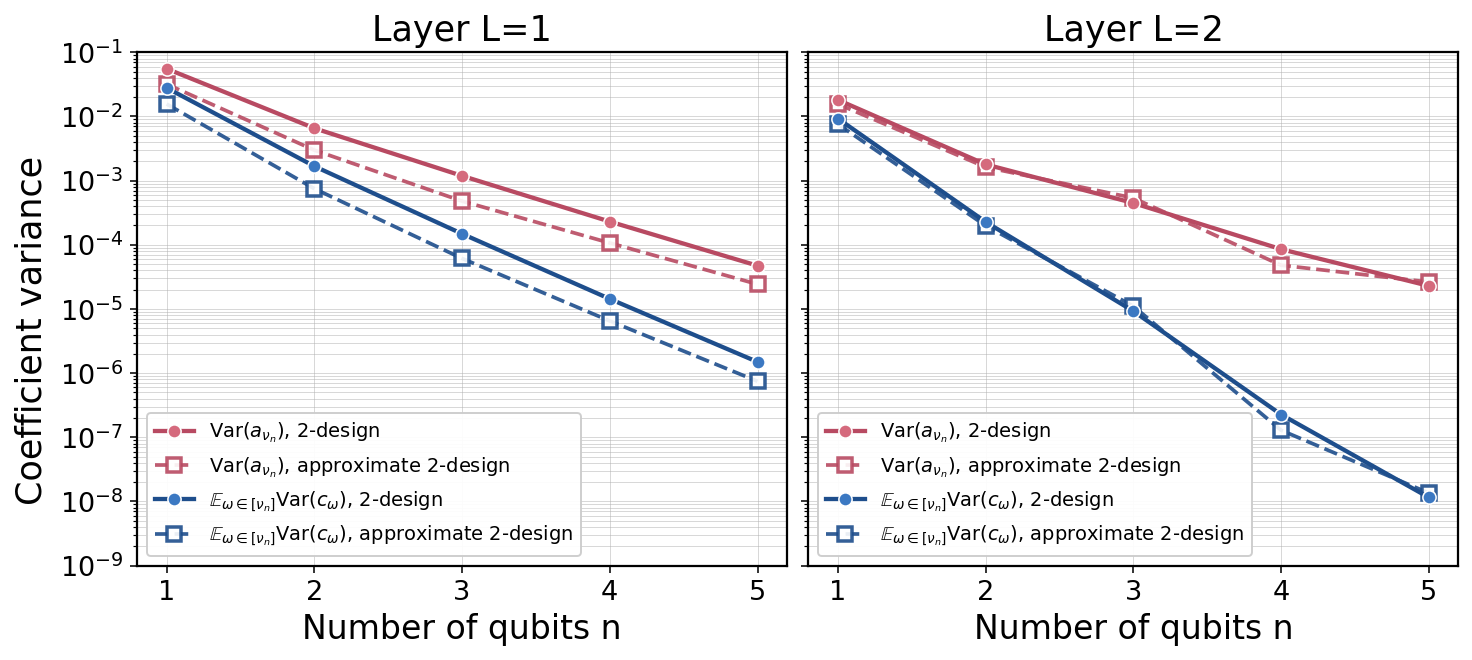

saved value comparison figure to figures/figure3_variance_values_comparison.png


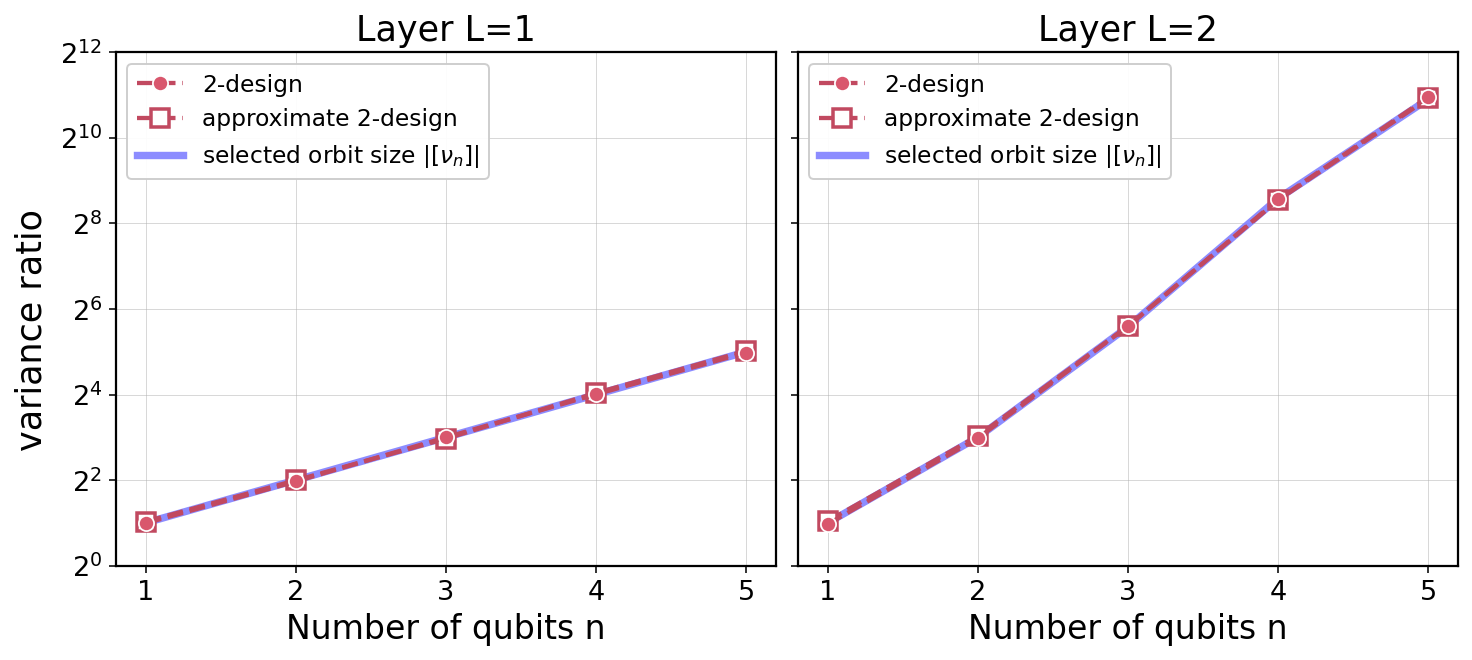

saved ratio comparison figure to figures/figure3_variance_ratio_comparison.png


In [34]:
VALUE_LEGEND_FONTSIZE = 10
RATIO_LEGEND_FONTSIZE = 12


def result_arrays(results):
    return {
        "n": np.array([item["n_qubits"] for item in results], dtype=float),
        "mean_c": np.array([item["mean_coefficient_variance"] for item in results], dtype=float),
        "var_a": np.array([item["aggregate_variance"] for item in results], dtype=float),
        "ratio": np.array([item["ratio"] for item in results], dtype=float),
        "orbit_size": np.array([item["orbit_size"] for item in results], dtype=float),
    }


def set_log_ylim(ax, values, base=10):
    positive_values = np.concatenate(values)
    positive_values = positive_values[np.isfinite(positive_values) & (positive_values > 0)]
    if not positive_values.size:
        return False
    if base == 2:
        lower = np.floor(np.log2(np.min(positive_values)) - 0.25)
        upper = np.ceil(np.log2(np.max(positive_values)) + 0.25)
        ax.set_ylim(2.0**lower, 2.0**upper)
        ax.set_yticks(2.0 ** np.arange(lower, upper + 1))
        ax.yaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext(base=2))
    else:
        lower = np.floor(np.log10(np.min(positive_values)) - 0.25)
        upper = np.ceil(np.log10(np.max(positive_values)) + 0.25)
        ax.set_ylim(10.0**lower, 10.0**upper)
    return True


def plot_variance_values(ax, results_blocks_n, results_blocks_1, title):
    blocks_n = result_arrays(results_blocks_n)
    block1 = result_arrays(results_blocks_1)
    line_var_a_n, = ax.plot(
        blocks_n["n"],
        blocks_n["var_a"],
        "o-",
        color="#B84A62",
        markerfacecolor="#D56A7D",
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=2.2,
        markersize=6.8,
        zorder=5,
        label=r"$\operatorname{Var}(a_{\nu_n})$, 2-design",
    )
    line_var_a_1, = ax.plot(
        block1["n"],
        block1["var_a"],
        "s--",
        color="#B84A62",
        markerfacecolor="white",
        markeredgecolor="#B84A62",
        markeredgewidth=1.8,
        linewidth=1.9,
        markersize=7.4,
        alpha=0.9,
        zorder=3,
        label=r"$\operatorname{Var}(a_{\nu_n})$, approximate 2-design",
    )
    line_mean_c_n, = ax.plot(
        blocks_n["n"],
        blocks_n["mean_c"],
        "o-",
        color="#1E4E8C",
        markerfacecolor="#3B78C2",
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=2.2,
        markersize=6.8,
        zorder=5,
        label=r"$\mathbb{E}_{\omega\in[\nu_n]}\operatorname{Var}(c_\omega)$, 2-design",
    )
    line_mean_c_1, = ax.plot(
        block1["n"],
        block1["mean_c"],
        "s--",
        color="#1E4E8C",
        markerfacecolor="white",
        markeredgecolor="#1E4E8C",
        markeredgewidth=1.8,
        linewidth=1.9,
        markersize=7.4,
        alpha=0.9,
        zorder=3,
        label=r"$\mathbb{E}_{\omega\in[\nu_n]}\operatorname{Var}(c_\omega)$, approximate 2-design",
    )
    if set_log_ylim(ax, [blocks_n["var_a"], block1["var_a"], blocks_n["mean_c"], block1["mean_c"]]):
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Number of qubits n")
    ax.set_ylabel("Coefficient variance")
    ax.set_xticks(blocks_n["n"].astype(int))
    ax.grid(True, which="both", linewidth=0.45, alpha=0.55)
    handles = [line_var_a_n, line_var_a_1, line_mean_c_n, line_mean_c_1]
    ax.legend(handles=handles, loc="lower left", frameon=True, framealpha=0.95, fontsize=VALUE_LEGEND_FONTSIZE)
    return handles


def plot_variance_ratio(ax, results_blocks_n, results_blocks_1, title):
    blocks_n = result_arrays(results_blocks_n)
    block1 = result_arrays(results_blocks_1)
    line_design, = ax.plot(
        blocks_n["n"],
        blocks_n["ratio"],
        "o--",
        color="#C14960",
        markerfacecolor="#D9576D",
        markeredgecolor="white",
        markeredgewidth=0.9,
        linewidth=2.2,
        markersize=7.8,
        zorder=5,
        label="2-design",
    )
    line_approximate, = ax.plot(
        block1["n"],
        block1["ratio"],
        "s--",
        color="#C14960",
        markerfacecolor="white",
        markeredgecolor="#C14960",
        markeredgewidth=1.8,
        linewidth=2.2,
        markersize=8.8,
        zorder=4,
        label="approximate 2-design",
    )
    line_orbit_size, = ax.plot(
        blocks_n["n"],
        blocks_n["orbit_size"],
        "-",
        color="#8080ff",
        linewidth=3.8,
        alpha=0.9,
        zorder=2,
        label=r"selected orbit size $|[\nu_n]|$",
    )
    if set_log_ylim(ax, [blocks_n["ratio"], block1["ratio"], blocks_n["orbit_size"]], base=2):
        ax.set_yscale("log", base=2)
    ax.set_title(title)
    ax.set_xlabel("Number of qubits n")
    ax.set_ylabel("variance ratio")
    ax.set_xticks(blocks_n["n"].astype(int))
    ax.grid(True, which="major", linewidth=0.45, alpha=0.55)
    handles = [line_design, line_approximate, line_orbit_size]
    ax.legend(handles=handles, loc="upper left", frameon=True, framealpha=0.95, fontsize=RATIO_LEGEND_FONTSIZE)
    return handles


value_fig, value_axes = plt.subplots(1, 2, figsize=(10.4, 4.6), sharey=True, constrained_layout=True)
plot_variance_values(value_axes[0], results_L1_blocks_n, results_L1_blocks_1, "Layer L=1")
plot_variance_values(value_axes[1], results_L2_blocks_n, results_L2_blocks_1, "Layer L=2")
value_axes[0].set_ylabel("")
value_axes[1].set_ylabel("")
value_fig.supylabel("Coefficient variance")

VALUES_COMPARISON_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
value_fig.savefig(VALUES_COMPARISON_FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"saved value comparison figure to {VALUES_COMPARISON_FIGURE_PATH}")

ratio_fig, ratio_axes = plt.subplots(1, 2, figsize=(10.4, 4.6), sharey=True, constrained_layout=True)
plot_variance_ratio(ratio_axes[0], results_L1_blocks_n, results_L1_blocks_1, "Layer L=1")
plot_variance_ratio(ratio_axes[1], results_L2_blocks_n, results_L2_blocks_1, "Layer L=2")
ratio_axes[0].set_ylabel("")
ratio_axes[1].set_ylabel("")
ratio_fig.supylabel("variance ratio")

RATIO_COMPARISON_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
ratio_fig.savefig(RATIO_COMPARISON_FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"saved ratio comparison figure to {RATIO_COMPARISON_FIGURE_PATH}")
